# Bubble dọc -> 1 line ngang cho OCR CTC

Notebook này triển khai POC xử lý **1 ảnh bubble manga** chứa chữ Nhật dọc thành **1 dải ảnh ngang** để thuận tiện cho CRNN/SVTR.

Pipeline chính:
1. Nhị phân hóa ảnh bubble.
2. Giảm ảnh hưởng Furigana bằng Morphological Opening/Erosion.
3. Dùng Vertical Projection Profile để tự động tách N cột dọc theo khe hở.
4. Sắp xếp cột theo trục X từ trái sang phải.
5. Xoay từng cột -90 độ (tương đương 90 độ clockwise trong OpenCV).
6. Stitch các cột thành 1 line ngang với spacer trắng.
7. Kiểm tra tương thích CTC theo chuẩn PaddleOCR CRNN.

## 1) Set Up Environment and Dependencies

Cell này import thư viện, thiết lập hiển thị và kiểm tra version tối thiểu để notebook chạy ổn định.

In [1]:
from __future__ import annotations

import json
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import List, Tuple, Optional, Dict, Any

import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["image.cmap"] = "gray"

print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)

OpenCV: 4.10.0
NumPy: 2.4.3


## 2) Define Problem Inputs and Baseline Configuration

Cell này định nghĩa cấu hình cho 1 ảnh đầu vào, tham số tách cột tự động, xử lý Furigana mức nhẹ và kiểm tra CTC.

In [2]:
@dataclass
class PipelineConfig:
    input_image: str = "manga109/rec/train/word_000113.png"  # De trong se tu tim anh dau tien trong manga109/rec/train
    manual_roi: Optional[Tuple[int, int, int, int]] = None  # (x, y, w, h)
    output_dir: str = "output/bubble_line_demo"

    # Nhi phan
    binarize_method: str = "otsu"  # "otsu" | "adaptive"
    gaussian_blur_ksize: int = 3

    # Furigana suppression (muc nhe)
    furigana_mode: str = "light"  # "light" | "strong"
    open_kernel_scale: float = 0.018
    erode_kernel_scale: float = 0.012

    # Vertical Projection + tach khe (da tang do nhay)
    smooth_window: int = 7
    gap_percentile: float = 30.0
    gap_scale: float = 1.0
    sensitivity_boost: float = 1.25  # >1.0 se de tach nhieu khe hon
    min_gap_width: int = 3
    min_col_width: int = 10
    col_pad_y: int = 2

    # Dieu khien threshold de tach lat cat
    gap_threshold_mode: str = "auto_percentile"  # "auto_percentile" | "fixed"
    gap_threshold_direction: str = "low"  # "low": profile <= threshold la khe; "high": profile >= threshold la khe
    gap_threshold_value: Optional[float] = None  # Chi dung khi mode="fixed"

    # Sap xep cot
    sort_right_to_left: bool = True  # True: phai -> trai, False: trai -> phai

    # Rotate + stitch
    spacer_px: int = 15
    rotate_angle: int = -90  # -90: ngược chiều kim đồng hồ, 90: cùng chiều


@dataclass
class CTCCompatConfig:
    image_shape: Tuple[int, int, int] = (3, 32, 100)
    max_text_length: int = 25


def auto_pick_input_image() -> str:
    candidates = list(Path("manga109/rec/train").glob("**/*"))
    image_ext = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    for p in candidates:
        if p.suffix.lower() in image_ext:
            return str(p)
    return ""


cfg = PipelineConfig()
if not cfg.input_image:
    cfg.input_image = auto_pick_input_image()
ctc_cfg = CTCCompatConfig()

print("Input image:", cfg.input_image if cfg.input_image else "<chua tim thay>")
print("Output dir:", cfg.output_dir)
print("Sort mode:", "right-to-left" if cfg.sort_right_to_left else "left-to-right")
print("Threshold mode:", cfg.gap_threshold_mode, "| direction:", cfg.gap_threshold_direction)
print("Sensitivity boost:", cfg.sensitivity_boost)
print("Rotate angle:", cfg.rotate_angle)

Input image: manga109/rec/train/word_000113.png
Output dir: output/bubble_line_demo
Sort mode: right-to-left
Threshold mode: auto_percentile | direction: low
Sensitivity boost: 1.25
Rotate angle: -90


## 3) Implement Core Functions

Các hàm cốt lõi cho: nạp ảnh, tiền xử lý, giảm Furigana, Vertical Projection split, xoay-ghép và hiển thị kết quả.

In [3]:
def show_image(img: np.ndarray, title: str = "", is_bgr: bool = True) -> None:
    if img is None:
        print(f"{title}: None")
        return
    plt.figure()
    if img.ndim == 2:
        plt.imshow(img, cmap="gray")
    elif is_bgr:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_grid(images: List[np.ndarray], titles: List[str], ncols: int = 4, bgr_flags: Optional[List[bool]] = None) -> None:
    if not images:
        print("Khong co anh de hien thi.")
        return
    if bgr_flags is None:
        bgr_flags = [True] * len(images)
    n = len(images)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
    axes = np.array(axes).reshape(-1)
    for i, ax in enumerate(axes):
        if i >= n:
            ax.axis("off")
            continue
        img = images[i]
        if img.ndim == 2:
            ax.imshow(img, cmap="gray")
        elif bgr_flags[i]:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            ax.imshow(img)
        ax.set_title(titles[i])
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def load_input_image(input_path: str, manual_roi: Optional[Tuple[int, int, int, int]]) -> Tuple[np.ndarray, np.ndarray]:
    if not input_path:
        raise FileNotFoundError("Khong tim thay input_image. Hay dat cfg.input_image.")
    src = cv2.imread(input_path, cv2.IMREAD_COLOR)
    if src is None:
        raise FileNotFoundError(f"Khong doc duoc anh: {input_path}")

    bubble = src
    if manual_roi is not None:
        x, y, w, h = manual_roi
        x = max(0, x)
        y = max(0, y)
        w = max(1, w)
        h = max(1, h)
        bubble = src[y:y + h, x:x + w].copy()
        if bubble.size == 0:
            raise ValueError("manual_roi khong hop le, crop ra anh rong.")
    return src, bubble


def _safe_kernel(size: int) -> int:
    size = max(1, int(size))
    if size % 2 == 0:
        size += 1
    return size


def preprocess_binarize(bgr: np.ndarray, cfg: PipelineConfig) -> Dict[str, np.ndarray]:
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    if cfg.gaussian_blur_ksize > 1:
        k = _safe_kernel(cfg.gaussian_blur_ksize)
        gray = cv2.GaussianBlur(gray, (k, k), 0)

    if cfg.binarize_method == "adaptive":
        bw = cv2.adaptiveThreshold(
            gray,
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV,
            31,
            10,
        )
    else:
        _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # text mask: text la 255, background la 0
    text_mask = bw
    return {"gray": gray, "text_mask": text_mask}


def suppress_furigana(mask: np.ndarray, cfg: PipelineConfig) -> Dict[str, np.ndarray]:
    h, w = mask.shape
    base = max(3, int(round(min(h, w) * cfg.open_kernel_scale)))
    base = _safe_kernel(base)
    erode_k = max(1, int(round(min(h, w) * cfg.erode_kernel_scale)))
    erode_k = _safe_kernel(erode_k)

    open_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (base, base))
    erode_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (erode_k, erode_k))

    opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, open_kernel, iterations=1)
    eroded = cv2.erode(mask, erode_kernel, iterations=1)

    if cfg.furigana_mode == "strong":
        cleaned = opened
    else:
        # Light mode: giam noise/Furigana nhe, van giu duong net chinh.
        cleaned = cv2.bitwise_or(opened, eroded)

    return {
        "opened": opened,
        "eroded": eroded,
        "cleaned_mask": cleaned,
        "open_kernel": open_kernel,
        "erode_kernel": erode_kernel,
    }


def smooth_profile(profile: np.ndarray, window: int) -> np.ndarray:
    window = max(1, int(window))
    if window == 1:
        return profile.astype(np.float32)
    kernel = np.ones(window, dtype=np.float32) / float(window)
    return np.convolve(profile.astype(np.float32), kernel, mode="same")


def find_gap_runs(mask_1d: np.ndarray, min_width: int) -> List[Tuple[int, int]]:
    runs: List[Tuple[int, int]] = []
    in_gap = False
    start = 0
    for i, val in enumerate(mask_1d):
        if val and not in_gap:
            in_gap = True
            start = i
        elif not val and in_gap:
            end = i - 1
            in_gap = False
            if end - start + 1 >= min_width:
                runs.append((start, end))
    if in_gap:
        end = len(mask_1d) - 1
        if end - start + 1 >= min_width:
            runs.append((start, end))
    return runs


def vertical_projection_split(mask: np.ndarray, cfg: PipelineConfig) -> Dict[str, Any]:
    h, w = mask.shape
    profile = np.sum(mask > 0, axis=0).astype(np.float32)
    profile_smooth = smooth_profile(profile, cfg.smooth_window)

    # Cat bo margin trang o 2 ben de projection on dinh hon
    nonzero_cols = np.where(profile > 0)[0]
    if len(nonzero_cols) == 0:
        return {
            "profile": profile,
            "profile_smooth": profile_smooth,
            "threshold": 0.0,
            "gaps": [],
            "intervals": [],
            "x_active": (0, w - 1),
        }

    x0_active, x1_active = int(nonzero_cols[0]), int(nonzero_cols[-1])
    active_profile = profile_smooth[x0_active : x1_active + 1]

    threshold = float(np.percentile(active_profile, cfg.gap_percentile) * cfg.gap_scale)
    gap_mask_active = active_profile <= threshold
    gaps_active = find_gap_runs(gap_mask_active, cfg.min_gap_width)
    gaps = [(a + x0_active, b + x0_active) for a, b in gaps_active]

    # Convert gaps -> text intervals (phan bu)
    intervals: List[Tuple[int, int]] = []
    cursor = x0_active
    for g0, g1 in gaps:
        if g0 - cursor >= cfg.min_col_width:
            intervals.append((cursor, g0 - 1))
        cursor = g1 + 1
    if x1_active - cursor + 1 >= cfg.min_col_width:
        intervals.append((cursor, x1_active))

    # Merge cac intervals qua sat nhau (anti over-split)
    merged: List[Tuple[int, int]] = []
    for cur in intervals:
        if not merged:
            merged.append(cur)
            continue
        p0, p1 = merged[-1]
        c0, c1 = cur
        if c0 - p1 <= max(2, cfg.min_gap_width // 2):
            merged[-1] = (p0, c1)
        else:
            merged.append(cur)

    return {
        "profile": profile,
        "profile_smooth": profile_smooth,
        "threshold": threshold,
        "gaps": gaps,
        "intervals": merged,
        "x_active": (x0_active, x1_active),
    }


def trim_column_y(mask: np.ndarray, x0: int, x1: int, pad_y: int = 2) -> Optional[Tuple[int, int]]:
    part = mask[:, x0 : x1 + 1]
    row_profile = np.sum(part > 0, axis=1)
    ys = np.where(row_profile > 0)[0]
    if len(ys) == 0:
        return None
    y0 = max(0, int(ys[0]) - pad_y)
    y1 = min(mask.shape[0] - 1, int(ys[-1]) + pad_y)
    return y0, y1


def extract_columns(
    bgr: np.ndarray,
    cleaned_mask: np.ndarray,
    intervals: List[Tuple[int, int]],
    cfg: PipelineConfig,
) -> List[Dict[str, Any]]:
    cols: List[Dict[str, Any]] = []
    for x0, x1 in intervals:
        if x1 <= x0:
            continue
        y_range = trim_column_y(cleaned_mask, x0, x1, cfg.col_pad_y)
        if y_range is None:
            continue
        y0, y1 = y_range
        crop = bgr[y0 : y1 + 1, x0 : x1 + 1].copy()
        if crop.size == 0:
            continue
        cols.append(
            {
                "bbox": (int(x0), int(y0), int(x1), int(y1)),
                "x_center": float((x0 + x1) / 2.0),
                "image": crop,
            }
        )

    cols.sort(key=lambda d: d["x_center"])
    return cols


def rotate_column(col_img: np.ndarray, clockwise: bool = False) -> np.ndarray:
    if clockwise:
        return cv2.rotate(col_img, cv2.ROTATE_90_CLOCKWISE)
    return cv2.rotate(col_img, cv2.ROTATE_90_COUNTERCLOCKWISE)


def resize_to_height(img: np.ndarray, target_h: int) -> np.ndarray:
    h, w = img.shape[:2]
    if h == target_h:
        return img
    new_w = max(1, int(round(w * target_h / float(h))))
    return cv2.resize(img, (new_w, target_h), interpolation=cv2.INTER_LINEAR)


def stitch_rotated_columns(columns: List[Dict[str, Any]], cfg: PipelineConfig) -> Dict[str, Any]:
    if not columns:
        raise ValueError("Khong co cot nao de xoay/ghép.")

    rotated = [rotate_column(c["image"], clockwise=cfg.rotate_clockwise) for c in columns]
    heights = [im.shape[0] for im in rotated]
    target_h = int(np.median(heights))
    target_h = max(8, target_h)

    normalized = [resize_to_height(im, target_h) for im in rotated]
    spacer = np.full((target_h, cfg.spacer_px, 3), 255, dtype=np.uint8)

    seq = []
    for i, im in enumerate(normalized):
        seq.append(im)
        if i < len(normalized) - 1 and cfg.spacer_px > 0:
            seq.append(spacer)

    stitched = np.concatenate(seq, axis=1)
    return {
        "rotated_columns": rotated,
        "normalized_columns": normalized,
        "stitched_line": stitched,
        "target_height": target_h,
    }


def draw_projection_debug(mask: np.ndarray, proj_info: Dict[str, Any]) -> np.ndarray:
    vis = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    for x0, x1 in proj_info.get("gaps", []):
        cv2.rectangle(vis, (x0, 0), (x1, vis.shape[0] - 1), (0, 255, 255), 1)
    for x0, x1 in proj_info.get("intervals", []):
        cv2.rectangle(vis, (x0, 0), (x1, vis.shape[0] - 1), (0, 255, 0), 1)
    return vis


def simulate_ctc_resize_metrics(img: np.ndarray, ctc_cfg: CTCCompatConfig) -> Dict[str, Any]:
    _, img_h, img_w = ctc_cfg.image_shape
    h, w = img.shape[:2]
    ratio = w / float(max(1, h))
    max_wh_ratio = img_w / float(img_h)
    resized_w = min(int(np.ceil(img_h * ratio)), img_w)
    valid_ratio = min(1.0, resized_w / float(img_w))

    warnings: List[str] = []
    if ratio > max_wh_ratio:
        warnings.append("Anh line qua dai so voi image_shape CRNN, se bi nen manh theo truc ngang.")
    if valid_ratio < 0.9:
        warnings.append("valid_ratio < 0.9: nguy co mat chi tiet theo thoi gian CTC.")

    return {
        "input_hw": (h, w),
        "wh_ratio": ratio,
        "max_wh_ratio": max_wh_ratio,
        "resized_w": resized_w,
        "valid_ratio": valid_ratio,
        "warnings": warnings,
    }


def save_artifacts(
    output_dir: str,
    input_path: str,
    bubble: np.ndarray,
    binary_mask: np.ndarray,
    cleaned_mask: np.ndarray,
    projection_debug: np.ndarray,
    columns: List[Dict[str, Any]],
    stitched_line: np.ndarray,
    meta: Dict[str, Any],
) -> Dict[str, str]:
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)

    p_bubble = out / "01_bubble.png"
    p_binary = out / "02_binary_mask.png"
    p_cleaned = out / "03_cleaned_mask.png"
    p_proj = out / "04_projection_debug.png"
    p_line = out / "05_stitched_line.png"

    cv2.imwrite(str(p_bubble), bubble)
    cv2.imwrite(str(p_binary), binary_mask)
    cv2.imwrite(str(p_cleaned), cleaned_mask)
    cv2.imwrite(str(p_proj), projection_debug)
    cv2.imwrite(str(p_line), stitched_line)

    col_paths = []
    for i, c in enumerate(columns, start=1):
        p = out / f"col_{i:02d}.png"
        cv2.imwrite(str(p), c["image"])
        col_paths.append(str(p))

    metadata = {
        "input_path": input_path,
        "num_columns": len(columns),
        "column_bboxes": [c["bbox"] for c in columns],
        "column_paths": col_paths,
        **meta,
    }
    p_json = out / "metadata.json"
    with open(p_json, "w", encoding="utf-8") as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)

    return {
        "bubble": str(p_bubble),
        "binary": str(p_binary),
        "cleaned": str(p_cleaned),
        "projection": str(p_proj),
        "line": str(p_line),
        "metadata": str(p_json),
    }


def visualize_pipeline(
    src: np.ndarray,
    bubble: np.ndarray,
    bin_mask: np.ndarray,
    cleaned_mask: np.ndarray,
    proj_info: Dict[str, Any],
    projection_debug: np.ndarray,
    columns: List[Dict[str, Any]],
    rotated_cols: List[np.ndarray],
    stitched_line: np.ndarray,
) -> None:
    # Dashboard tong quan
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.reshape(-1)

    axes[0].imshow(cv2.cvtColor(src, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Anh goc")
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(bubble, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Bubble input")
    axes[1].axis("off")

    axes[2].imshow(bin_mask, cmap="gray")
    axes[2].set_title("Binary text mask")
    axes[2].axis("off")

    axes[3].imshow(cleaned_mask, cmap="gray")
    axes[3].set_title("Mask sau Furigana suppression")
    axes[3].axis("off")

    axes[4].imshow(cv2.cvtColor(projection_debug, cv2.COLOR_BGR2RGB))
    axes[4].set_title("Gap/Interval tren projection")
    axes[4].axis("off")

    axes[5].plot(proj_info["profile"], label="profile")
    axes[5].plot(proj_info["profile_smooth"], label="smooth")
    axes[5].axhline(proj_info["threshold"], color="r", linestyle="--", label="threshold")
    axes[5].set_title("Vertical Projection Profile")
    axes[5].legend()

    plt.tight_layout()
    plt.show()

    # Cot cat duoc
    show_grid(
        [c["image"] for c in columns],
        [f"col {i+1} | bbox={c['bbox']}" for i, c in enumerate(columns)],
        ncols=4,
        bgr_flags=[True] * len(columns),
    )

    # Cot da xoay
    show_grid(
        rotated_cols,
        [f"rot {i+1}" for i in range(len(rotated_cols))],
        ncols=4,
        bgr_flags=[True] * len(rotated_cols),
    )

    show_image(stitched_line, "Final stitched horizontal line", is_bgr=True)

### Nâng cấp: đảo chiều sắp xếp và điều khiển threshold tách cột

Cell này ghi đè 2 hàm `vertical_projection_split` và `extract_columns` để:
- Sắp xếp cột theo `sort_right_to_left`.
- Cho phép threshold tự động hoặc cố định, và chọn hướng so sánh (`low`/`high`).

In [4]:
def vertical_projection_split(mask: np.ndarray, cfg: PipelineConfig) -> Dict[str, Any]:
    h, w = mask.shape
    profile = np.sum(mask > 0, axis=0).astype(np.float32)
    profile_smooth = smooth_profile(profile, cfg.smooth_window)

    nonzero_cols = np.where(profile > 0)[0]
    if len(nonzero_cols) == 0:
        return {
            "profile": profile,
            "profile_smooth": profile_smooth,
            "threshold": 0.0,
            "gaps": [],
            "intervals": [],
            "x_active": (0, w - 1),
            "effective_min_gap": cfg.min_gap_width,
        }

    x0_active, x1_active = int(nonzero_cols[0]), int(nonzero_cols[-1])
    active_profile = profile_smooth[x0_active : x1_active + 1]

    mode = getattr(cfg, "gap_threshold_mode", "auto_percentile")
    direction = getattr(cfg, "gap_threshold_direction", "low")
    fixed_value = getattr(cfg, "gap_threshold_value", None)
    sensitivity_boost = float(getattr(cfg, "sensitivity_boost", 1.0))

    if mode == "fixed" and fixed_value is not None:
        threshold = float(fixed_value)
    else:
        threshold = float(np.percentile(active_profile, cfg.gap_percentile) * cfg.gap_scale)

    if direction == "low":
        threshold = threshold * max(0.5, sensitivity_boost)

    effective_min_gap = max(2, int(round(cfg.min_gap_width / max(0.5, sensitivity_boost))))

    if direction == "high":
        gap_mask_active = active_profile >= threshold
    else:
        gap_mask_active = active_profile <= threshold

    gaps_active = find_gap_runs(gap_mask_active, effective_min_gap)

    # Fallback tang nhay neu van chua tim du khe
    if len(gaps_active) == 0 and direction == "low" and mode != "fixed":
        threshold_fallback = min(
            float(np.max(active_profile)),
            threshold + float(np.std(active_profile) * 0.25 * max(1.0, sensitivity_boost)),
        )
        gap_mask_active = active_profile <= threshold_fallback
        gaps_active = find_gap_runs(gap_mask_active, effective_min_gap)
        threshold = threshold_fallback

    gaps = [(a + x0_active, b + x0_active) for a, b in gaps_active]

    intervals: List[Tuple[int, int]] = []
    cursor = x0_active
    for g0, g1 in gaps:
        if g0 - cursor >= cfg.min_col_width:
            intervals.append((cursor, g0 - 1))
        cursor = g1 + 1
    if x1_active - cursor + 1 >= cfg.min_col_width:
        intervals.append((cursor, x1_active))

    merged: List[Tuple[int, int]] = []
    for cur in intervals:
        if not merged:
            merged.append(cur)
            continue
        p0, p1 = merged[-1]
        c0, c1 = cur
        if c0 - p1 <= max(2, effective_min_gap // 2):
            merged[-1] = (p0, c1)
        else:
            merged.append(cur)

    return {
        "profile": profile,
        "profile_smooth": profile_smooth,
        "threshold": threshold,
        "gaps": gaps,
        "intervals": merged,
        "x_active": (x0_active, x1_active),
        "threshold_mode": mode,
        "threshold_direction": direction,
        "effective_min_gap": effective_min_gap,
        "sensitivity_boost": sensitivity_boost,
    }


def extract_columns(
    bgr: np.ndarray,
    cleaned_mask: np.ndarray,
    intervals: List[Tuple[int, int]],
    cfg: PipelineConfig,
) -> List[Dict[str, Any]]:
    cols: List[Dict[str, Any]] = []
    for x0, x1 in intervals:
        if x1 <= x0:
            continue
        y_range = trim_column_y(cleaned_mask, x0, x1, cfg.col_pad_y)
        if y_range is None:
            continue
        y0, y1 = y_range
        crop = bgr[y0 : y1 + 1, x0 : x1 + 1].copy()
        if crop.size == 0:
            continue
        cols.append(
            {
                "bbox": (int(x0), int(y0), int(x1), int(y1)),
                "x_center": float((x0 + x1) / 2.0),
                "image": crop,
            }
        )

    reverse_sort = bool(getattr(cfg, "sort_right_to_left", False))
    cols.sort(key=lambda d: d["x_center"], reverse=reverse_sort)
    return cols

### Nang cap: xoay theo goc cau hinh (mac dinh -90 do CCW)

Cell nay ghi de ham xoay de dung tham so `rotate_angle`.
- `-90`: xoay nguoc chieu kim dong ho (CCW).
- `90`: xoay cung chieu kim dong ho (CW).

In [5]:
def rotate_column(col_img: np.ndarray, rotate_angle: int = -90) -> np.ndarray:
    if rotate_angle == 90:
        return cv2.rotate(col_img, cv2.ROTATE_90_CLOCKWISE)
    if rotate_angle == -90:
        return cv2.rotate(col_img, cv2.ROTATE_90_COUNTERCLOCKWISE)
    raise ValueError("rotate_angle chi nhan 90 hoac -90")


def stitch_rotated_columns(columns: List[Dict[str, Any]], cfg: PipelineConfig) -> Dict[str, Any]:
    if not columns:
        raise ValueError("Khong co cot nao de xoay/ghep.")

    rotated = [rotate_column(c["image"], rotate_angle=cfg.rotate_angle) for c in columns]
    heights = [im.shape[0] for im in rotated]
    target_h = int(np.median(heights))
    target_h = max(8, target_h)

    normalized = [resize_to_height(im, target_h) for im in rotated]
    spacer = np.full((target_h, cfg.spacer_px, 3), 255, dtype=np.uint8)

    seq = []
    for i, im in enumerate(normalized):
        seq.append(im)
        if i < len(normalized) - 1 and cfg.spacer_px > 0:
            seq.append(spacer)

    stitched = np.concatenate(seq, axis=1)
    return {
        "rotated_columns": rotated,
        "normalized_columns": normalized,
        "stitched_line": stitched,
        "target_height": target_h,
    }

## 4) Add Input Validation and Error Handling

Cell này bổ sung guard clauses để pipeline lỗi rõ ràng khi thiếu input hoặc tham số sai.

In [6]:
def validate_config(cfg: PipelineConfig) -> None:
    if cfg.smooth_window < 1:
        raise ValueError("smooth_window phai >= 1")
    if cfg.min_gap_width < 1:
        raise ValueError("min_gap_width phai >= 1")
    if cfg.min_col_width < 2:
        raise ValueError("min_col_width phai >= 2")
    if cfg.spacer_px < 0:
        raise ValueError("spacer_px khong duoc am")
    if cfg.binarize_method not in {"otsu", "adaptive"}:
        raise ValueError("binarize_method chi nhan 'otsu' hoac 'adaptive'")
    if cfg.furigana_mode not in {"light", "strong"}:
        raise ValueError("furigana_mode chi nhan 'light' hoac 'strong'")
    if not (0 <= cfg.gap_percentile <= 100):
        raise ValueError("gap_percentile phai trong [0, 100]")

    if cfg.gap_threshold_mode not in {"auto_percentile", "fixed"}:
        raise ValueError("gap_threshold_mode chi nhan 'auto_percentile' hoac 'fixed'")
    if cfg.gap_threshold_direction not in {"low", "high"}:
        raise ValueError("gap_threshold_direction chi nhan 'low' hoac 'high'")
    if cfg.gap_threshold_mode == "fixed" and cfg.gap_threshold_value is None:
        raise ValueError("gap_threshold_value phai duoc dat khi gap_threshold_mode='fixed'")

    if cfg.rotate_angle not in {90, -90}:
        raise ValueError("rotate_angle chi nhan 90 hoac -90")

    if cfg.sensitivity_boost <= 0:
        raise ValueError("sensitivity_boost phai > 0")


def validate_input_path(path: str) -> None:
    if not path:
        raise FileNotFoundError("Khong co input_image. Hay set cfg.input_image.")
    if not Path(path).exists():
        raise FileNotFoundError(f"Duong dan input khong ton tai: {path}")


validate_config(cfg)
validate_input_path(cfg.input_image)
print("Validation OK")

Validation OK


## 5) Run Unit-Style Checks in Notebook

Tạo test nhỏ với ảnh tổng hợp để kiểm tra logic tách khe và tách cột không bị vỡ.

In [7]:
def make_synthetic_vertical_mask(h: int = 220, w: int = 180) -> np.ndarray:
    mask = np.zeros((h, w), dtype=np.uint8)
    # 3 cot text gia lap, giua cac cot co khe trang ro
    cv2.rectangle(mask, (15, 20), (45, 200), 255, -1)
    cv2.rectangle(mask, (70, 25), (103, 198), 255, -1)
    cv2.rectangle(mask, (128, 15), (164, 205), 255, -1)

    # Gia lap furigana nho sat cot thu 2
    for y in range(30, 190, 18):
        cv2.rectangle(mask, (108, y), (114, y + 5), 255, -1)
    return mask


def unit_style_checks() -> None:
    test_cfg = PipelineConfig(
        input_image="dummy.png",
        smooth_window=7,
        min_gap_width=4,
        min_col_width=10,
        furigana_mode="light",
    )
    mask = make_synthetic_vertical_mask()
    furigana = suppress_furigana(mask, test_cfg)
    proj = vertical_projection_split(furigana["cleaned_mask"], test_cfg)

    assert len(proj["intervals"]) >= 3, f"Expected >=3 intervals, got {len(proj['intervals'])}"

    # Tao bubble mau BGR tu mask de test extract + stitch
    bubble = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    cols = extract_columns(bubble, furigana["cleaned_mask"], proj["intervals"], test_cfg)
    assert len(cols) >= 3, f"Expected >=3 columns, got {len(cols)}"

    st = stitch_rotated_columns(cols, test_cfg)
    assert st["stitched_line"].shape[0] > 0 and st["stitched_line"].shape[1] > 0

    print("Unit-style checks passed.")


unit_style_checks()

Unit-style checks passed.


## 6) Execute Sample Workflow and Inspect Output

Cell này chạy end-to-end trên 1 ảnh input thực tế và in summary ngắn.

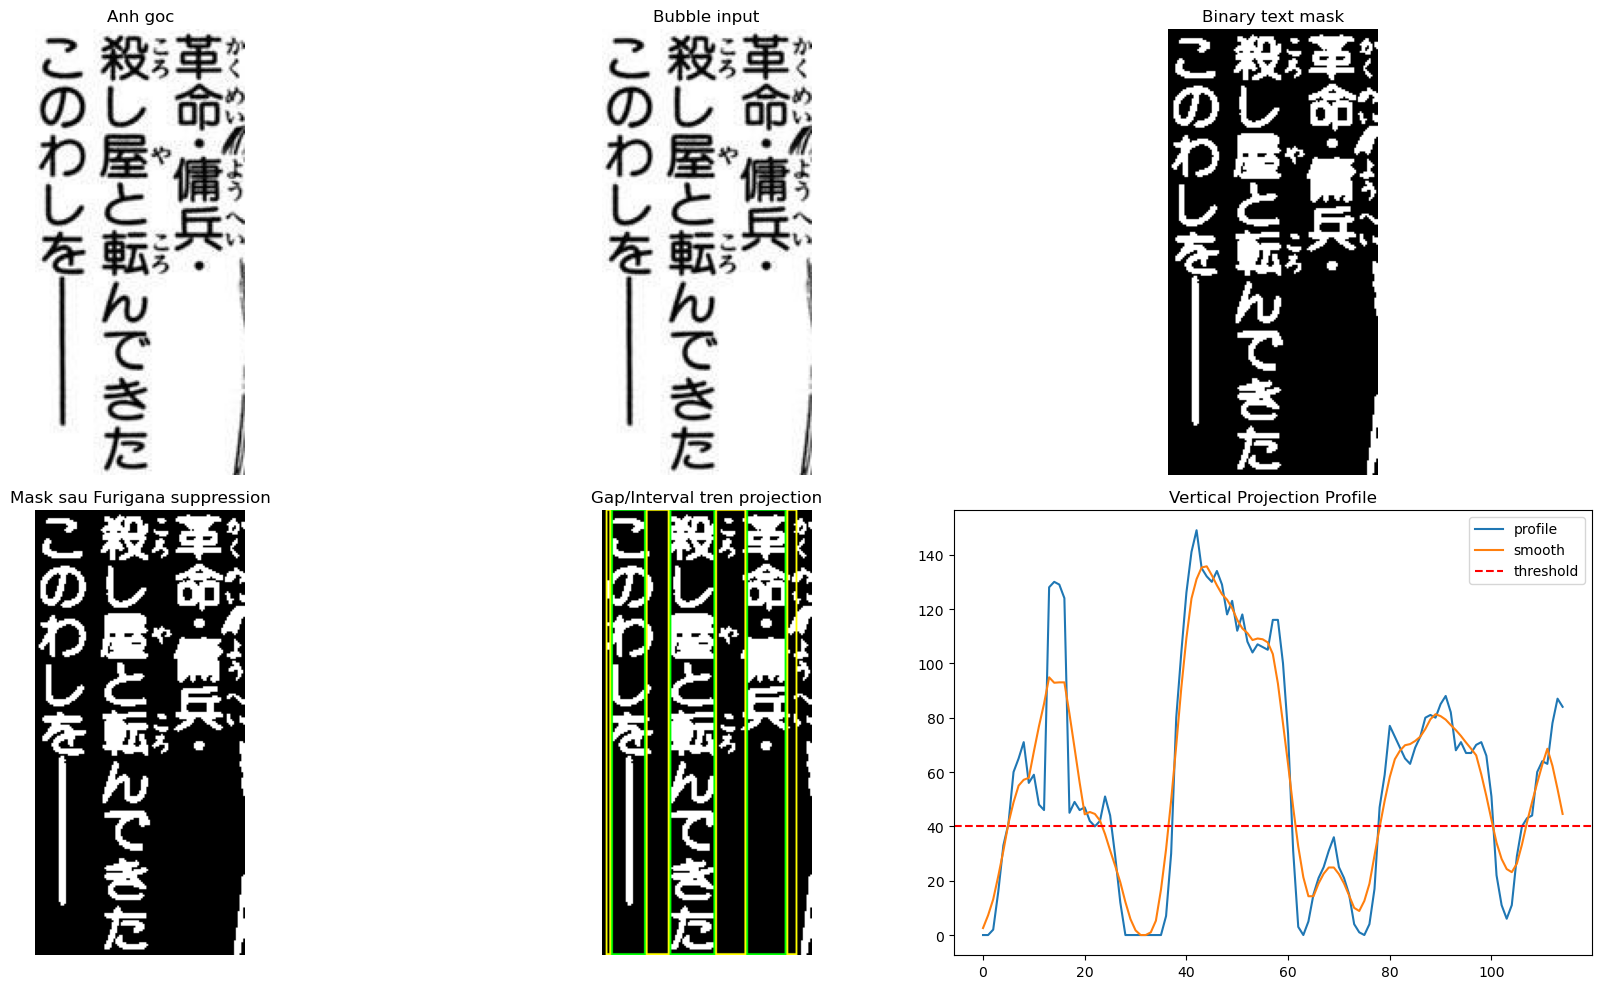

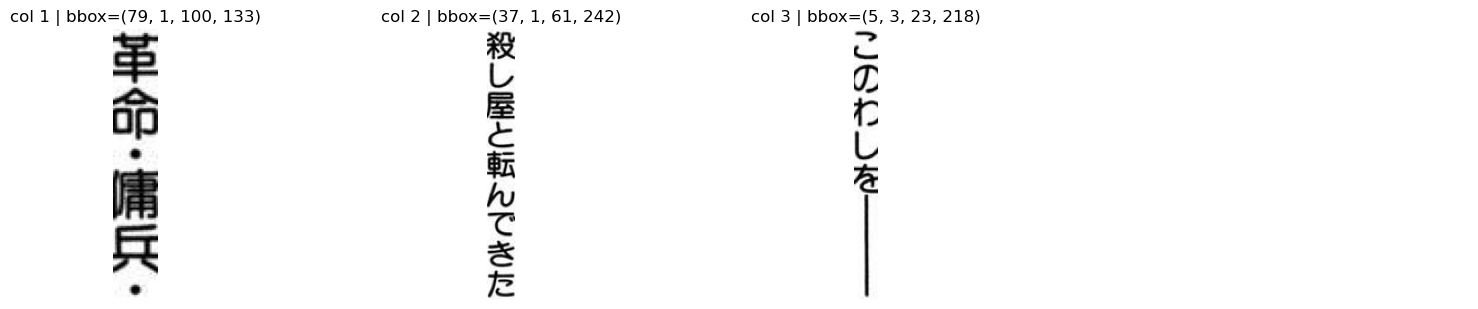

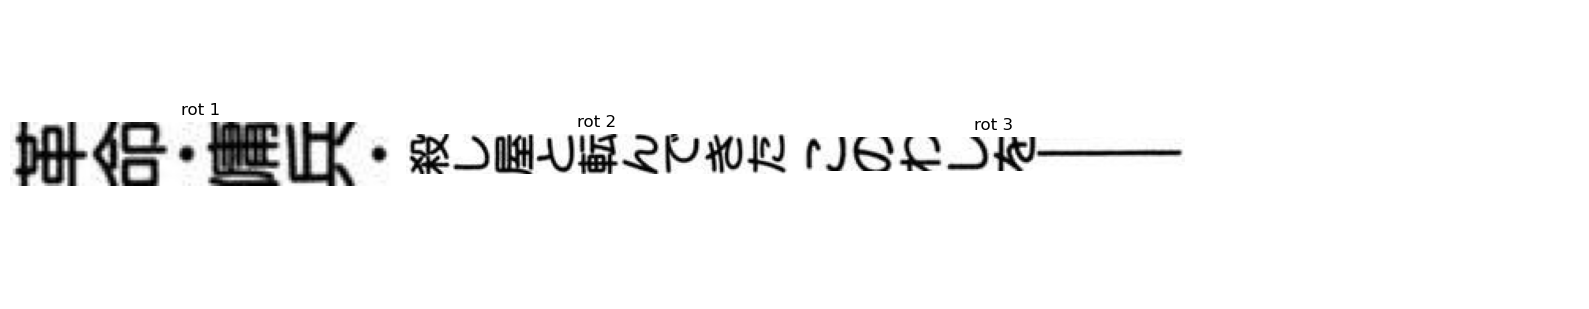

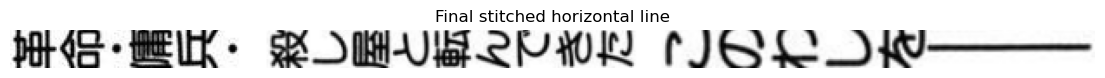


=== SUMMARY ===
Sort: right-to-left
Threshold mode: auto_percentile
Threshold direction: low
So cot tu dong N: 3
Intervals: [(5, 23), (37, 61), (79, 100)]
Final line shape (H, W): (22, 626)
CTC wh_ratio: 28.4545
CTC valid_ratio estimate: 1.0
Canh bao:
- Anh line qua dai so voi image_shape CRNN, se bi nen manh theo truc ngang.
Artifacts da luu:
  bubble: output\bubble_line_demo\01_bubble.png
  binary: output\bubble_line_demo\02_binary_mask.png
  cleaned: output\bubble_line_demo\03_cleaned_mask.png
  projection: output\bubble_line_demo\04_projection_debug.png
  line: output\bubble_line_demo\05_stitched_line.png
  metadata: output\bubble_line_demo\metadata.json


In [8]:
# Chay workflow tren 1 anh
src_img, bubble_img = load_input_image(cfg.input_image, cfg.manual_roi)
pre = preprocess_binarize(bubble_img, cfg)
fur = suppress_furigana(pre["text_mask"], cfg)
proj = vertical_projection_split(fur["cleaned_mask"], cfg)
cols = extract_columns(bubble_img, fur["cleaned_mask"], proj["intervals"], cfg)

if len(cols) == 0:
    raise RuntimeError("Khong tach duoc cot nao. Thu giam min_col_width hoac doi threshold.")

stitched = stitch_rotated_columns(cols, cfg)
ctc_metrics = simulate_ctc_resize_metrics(stitched["stitched_line"], ctc_cfg)
projection_debug = draw_projection_debug(fur["cleaned_mask"], proj)

meta = {
    "projection": {
        "threshold": proj["threshold"],
        "num_gaps": len(proj["gaps"]),
        "num_intervals": len(proj["intervals"]),
        "intervals": proj["intervals"],
        "threshold_mode": proj.get("threshold_mode", cfg.gap_threshold_mode),
        "threshold_direction": proj.get("threshold_direction", cfg.gap_threshold_direction),
    },
    "ctc_metrics": ctc_metrics,
    "params": asdict(cfg),
}

saved = save_artifacts(
    output_dir=cfg.output_dir,
    input_path=cfg.input_image,
    bubble=bubble_img,
    binary_mask=pre["text_mask"],
    cleaned_mask=fur["cleaned_mask"],
    projection_debug=projection_debug,
    columns=cols,
    stitched_line=stitched["stitched_line"],
    meta=meta,
)

visualize_pipeline(
    src=src_img,
    bubble=bubble_img,
    bin_mask=pre["text_mask"],
    cleaned_mask=fur["cleaned_mask"],
    proj_info=proj,
    projection_debug=projection_debug,
    columns=cols,
    rotated_cols=stitched["rotated_columns"],
    stitched_line=stitched["stitched_line"],
)

print("\n=== SUMMARY ===")
print("Sort:", "right-to-left" if cfg.sort_right_to_left else "left-to-right")
print("Threshold mode:", cfg.gap_threshold_mode)
print("Threshold direction:", cfg.gap_threshold_direction)
if cfg.gap_threshold_mode == "fixed":
    print("Threshold fixed value:", cfg.gap_threshold_value)
print("So cot tu dong N:", len(cols))
print("Intervals:", proj["intervals"])
print("Final line shape (H, W):", stitched["stitched_line"].shape[:2])
print("CTC wh_ratio:", round(ctc_metrics["wh_ratio"], 4))
print("CTC valid_ratio estimate:", round(ctc_metrics["valid_ratio"], 4))
if ctc_metrics["warnings"]:
    print("Canh bao:")
    for w in ctc_metrics["warnings"]:
        print("-", w)
print("Artifacts da luu:")
for k, v in saved.items():
    print(f"  {k}: {v}")

## 7) Refactor Into Reusable Components

Cell này gom pipeline thành một hàm duy nhất để tái sử dụng cho script hoặc notebook khác.

In [9]:
def bubble_to_horizontal_line(
    input_image: str,
    cfg: Optional[PipelineConfig] = None,
    ctc_cfg: Optional[CTCCompatConfig] = None,
) -> Dict[str, Any]:
    cfg = cfg or PipelineConfig()
    ctc_cfg = ctc_cfg or CTCCompatConfig()
    cfg.input_image = input_image

    validate_config(cfg)
    validate_input_path(cfg.input_image)

    src_img, bubble_img = load_input_image(cfg.input_image, cfg.manual_roi)
    pre = preprocess_binarize(bubble_img, cfg)
    fur = suppress_furigana(pre["text_mask"], cfg)
    proj = vertical_projection_split(fur["cleaned_mask"], cfg)
    cols = extract_columns(bubble_img, fur["cleaned_mask"], proj["intervals"], cfg)
    if len(cols) == 0:
        raise RuntimeError("Khong tach duoc cot nao tu bubble input.")

    stitched = stitch_rotated_columns(cols, cfg)
    ctc_metrics = simulate_ctc_resize_metrics(stitched["stitched_line"], ctc_cfg)
    projection_debug = draw_projection_debug(fur["cleaned_mask"], proj)

    meta = {
        "projection": {
            "threshold": proj["threshold"],
            "num_gaps": len(proj["gaps"]),
            "num_intervals": len(proj["intervals"]),
            "intervals": proj["intervals"],
        },
        "ctc_metrics": ctc_metrics,
        "params": asdict(cfg),
    }
    saved = save_artifacts(
        output_dir=cfg.output_dir,
        input_path=cfg.input_image,
        bubble=bubble_img,
        binary_mask=pre["text_mask"],
        cleaned_mask=fur["cleaned_mask"],
        projection_debug=projection_debug,
        columns=cols,
        stitched_line=stitched["stitched_line"],
        meta=meta,
    )

    return {
        "src": src_img,
        "bubble": bubble_img,
        "binary": pre["text_mask"],
        "cleaned": fur["cleaned_mask"],
        "projection": proj,
        "columns": cols,
        "stitched": stitched,
        "ctc_metrics": ctc_metrics,
        "saved_paths": saved,
    }


print("Reusable function ready: bubble_to_horizontal_line(input_image, cfg, ctc_cfg)")

Reusable function ready: bubble_to_horizontal_line(input_image, cfg, ctc_cfg)
